Principal component regression is a linear regression technique that involves principal component analysis (PCA).
It is especially used to overcome the problem with collinearity in linear regression by combining explainatory variables to a smaller set of uncorrelated variables.

To explain how PCR works, let's consider the following dataset:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
data = {
  "SBP": [132.1, 129.9, 131.2, 132.1, 125.0, 129.1, 133.1, 127.0, 131.6, 129.2],
  "DBP": [82.6, 79.1, 81.7, 80.7, 74.9, 79.1, 83.8, 78.4, 82.3, 79.4],
  "Weight": [71, 79, 78, 66, 70, 64, 60, 67, 64, 77],
  "Height": [172, 180, 172, 166, 173, 162, 164, 165, 164, 179],
  "Age": [45, 50, 38, 60, 55, 42, 48, 53, 40, 47]
}

data = pd.DataFrame(data)

print(data) 

     SBP   DBP  Weight  Height  Age
0  132.1  82.6      71     172   45
1  129.9  79.1      79     180   50
2  131.2  81.7      78     172   38
3  132.1  80.7      66     166   60
4  125.0  74.9      70     173   55
5  129.1  79.1      64     162   42
6  133.1  83.8      60     164   48
7  127.0  78.4      67     165   53
8  131.6  82.3      64     164   40
9  129.2  79.4      77     179   47


Suppose that we like to predict the age, based on the four explainatory variables: systolic blood pressure, diastolic blood pressure, weight, and height.

Since we have more than one explainatory varibales in our model, we will use multiple linear regression:
$$  \text{Age} = \text{intercept} + \text{SBP} + \text{DBP} + \text{Weight} + \text{Height} $$
However, it is problematic to use a multiple linear regression if there is strong corretlation between explainatory variables. A linear association between the explainatory variables in called collinearity.

In [3]:
correlation_matrix = data[["Age", "SBP", "DBP", "Weight", "Height"]].corr()
print(correlation_matrix)

             Age       SBP       DBP    Weight    Height
Age     1.000000 -0.315333 -0.459151 -0.126193  0.070678
SBP    -0.315333  1.000000  0.950954 -0.194782 -0.210057
DBP    -0.459151  0.950954  1.000000 -0.259351 -0.298309
Weight -0.126193 -0.194782 -0.259351  1.000000  0.902233
Height  0.070678 -0.210057 -0.298309  0.902233  1.000000


We see by the correlation matrix, that there is a strong positive correlation between SBP and DBP, and between weight and height. This model will therefore suffer from collinearity, which means that interpretation of the model coefficients will not be reliable due to inflation in the standard errors.

In [4]:
X_multi = data[["SBP", "DBP", "Weight", "Height"]]
y = data["Age"]

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("\nMultiple regression (Age ~ SBP + DBP + Weight + Height)")
print("Intercept:", model_multi.intercept_)
print("Coefficients [SBP, DBP, Weight, Height]:", model_multi.coef_)


Multiple regression (Age ~ SBP + DBP + Weight + Height)
Intercept: -84.96898052319678
Coefficients [SBP, DBP, Weight, Height]: [ 3.45035262 -4.56744968 -0.94208108  0.68354706]


We see that the estimated parameter value associated with the SBP is positive, whereas the estimated parameter value associated with the DBP is negative (same for weight and height). This does not make sense because we know that there is a positive correlation between these variables. This is due to collinarity. One way to deal with the problem of collinearity is to delete one of the explainatory variables. However, we might then remove important information.

Instead of deleting one of the variables, we could combine the correlated ones.

One way is to combine the variables by using principal component analysis, where we use the principal components (PC1 and PC2) as our combined variables. In such a model, each estimated parameters will be positive and the confidence intervals will be a lot narrower. This is the main reason why we should use princiapl component regression when we have collinearity in our model.

If we would perform PCA on these four variables, we would end up following weights that represent the first four eigenvectors of the covariance matrix.

Let's calculate these weights:

In [6]:
data['SBP_c']  = (data['SBP']  - data['SBP'].mean())
data['DBP_c']  = (data['DBP']  - data['DBP'].mean())
data['Weight_c'] = (data['Weight'] - data['Weight'].mean())
data['Height_c'] = (data['Height'] - data['Height'].mean())

features = ['SBP_c', 'DBP_c', 'Weight_c', 'Height_c']
cov_matrix = data[features].cov()
print("Covariance Matrix:\n", cov_matrix.round(2))
print("\n")
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted  = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

print("Sorted eigenvalues:\n", eigenvalues_sorted.round(2))
print("\n")
loadings = pd.DataFrame(
    eigenvectors_sorted,
    index=features,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
print("Loadings (Eigenvectors):\n", loadings.round(2))
print("\n")

# Compute PC scores with sorted eigenvectors
X = data[['SBP_c', 'DBP_c', 'Weight_c', 'Height_c']].to_numpy()
PC_scores = X @ eigenvectors_sorted

# Assign PC1, PC2, ... according to descending variance
data['PC1'] = PC_scores[:, 0]  # largest variance
data['PC2'] = PC_scores[:, 1]
data['PC3'] = PC_scores[:, 2]
data['PC4'] = PC_scores[:, 3]

print("PC Scores:\n", data[['PC1', 'PC2', 'PC3', 'PC4']].round(2))

Covariance Matrix:
           SBP_c  DBP_c  Weight_c  Height_c
SBP_c      6.43   6.23     -3.25     -3.43
DBP_c      6.23   6.67     -4.41     -4.97
Weight_c  -3.25  -4.41     43.38     38.31
Height_c  -3.43  -4.97     38.31     41.57


Sorted eigenvalues:
 [81.75 11.87  4.13  0.29]


Loadings (Eigenvectors):
            PC1   PC2   PC3   PC4
SBP_c     0.07  0.70  0.08  0.70
DBP_c     0.09  0.70  0.00 -0.71
Weight_c -0.71  0.12 -0.69  0.02
Height_c -0.69  0.04  0.72 -0.05


PC Scores:
      PC1   PC2   PC3   PC4
0  -2.22  3.39  0.85 -0.32
1 -13.94  0.70  0.86  0.41
2  -7.34  3.00 -4.07 -0.15
3   5.32  1.22  0.01  1.20
4  -3.42 -7.07  1.67  0.06
5   9.16 -2.41 -1.72  0.37
6  11.33  3.27  2.82 -0.34
7   4.73 -3.89 -1.82 -0.69
8   8.24  1.66 -0.07 -0.24
9 -11.85  0.13  1.47 -0.30


In the loadings table, each column is one eigenvector (i.e., one principal component).

Each eigenvector gives you how strongly each original variable contributes to that principal component.

Since we used PCA based on four variables, we will get four princiapl components. PCs are generated by these equations, using eigenvectors value as weights:
$$ \text{PC1}_i = + 0.07 * \text{cSBP}_i + 0.09 * \text{cDBP}_i - 0.71 * \text{cWeight}_i - 0.69 * \text{cHeight}_i $$
$$ \text{PC2}_i = + 0.70 * \text{cSBP}_i + 0.70 * \text{cDBP}_i + 0.12 * \text{cWeight}_i + 0.04 * \text{cHeight}_i $$
$$ \text{PC3}_i = + 0.08 * \text{cSBP}_i + 0.00 * \text{cDBP}_i - 0.69 * \text{cWeight}_i + 0.72 * \text{cHeight}_i $$
$$ \text{PC4}_i = + 0.70 * \text{cSBP}_i - 0.71 * \text{cDBP}_i + 0.02 * \text{cWeight}_i - 0.05 * \text{cHeight}_i $$

In [7]:
cov_matrix = data[['PC1', 'PC2', 'PC3', 'PC4']].cov()
cov_matrix = cov_matrix.round(2)
print(cov_matrix)

       PC1    PC2   PC3   PC4
PC1  81.75   0.00 -0.00 -0.00
PC2   0.00  11.87  0.00  0.00
PC3  -0.00   0.00  4.13 -0.00
PC4  -0.00   0.00 -0.00  0.29


As you can see PCs variances, are equal to eigenvalues!

When we transorm the data using PCA, the first variable named PC1 has a variance of 81.75, whereas PC2 has 11.87, PC3 has 4.13, and PC4 has 0.29. This means that almost all variance (95.5% of the total variance) is kept in the first and second principal components:
$$
\text{var percentage} = \frac{81.75 + 11.87}{81.75 + 11.87 + 4.13 + 0.29} = 0.955
$$
We therefore delete PC3 and PC4.

We are now ready to compute principal components regression, where we simply perform linear regression by using PC1 and PC2 as the explainatory variables.
$$  \text{Age} = \text{intercept} + \text{PC1} + \text{PC2} $$

In [8]:
X_multi = data[["PC1", "PC2"]]
y = data["Age"]

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("\nMultiple regression (Age ~ PC1 + PC2)")
print("Intercept:", model_multi.intercept_)
print("Coefficients [PC1, PC2]:", model_multi.coef_)


Multiple regression (Age ~ PC1 + PC2)
Intercept: 47.800000000000004
Coefficients [PC1, PC2]: [ 0.00904819 -0.86174937]


$$ \text{Age}_i = 47.8 + 0.0090 * \text{PC1}_i - 0.8617 * \text{PC2}_i $$

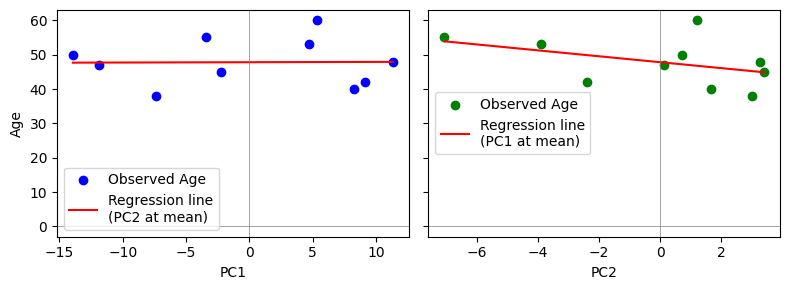

In [16]:
b0 = model_multi.intercept_
b1, b2 = model_multi.coef_
pc1_mean = data["PC1"].mean()
pc2_mean = data["PC2"].mean()

pc1_grid = np.linspace(data["PC1"].min(), data["PC1"].max(), 100)
age_pred_pc1 = b0 + b1 * pc1_grid + b2 * pc2_mean

pc2_grid = np.linspace(data["PC2"].min(), data["PC2"].max(), 100)
age_pred_pc2 = b0 + b1 * pc1_mean + b2 * pc2_grid

# ---------- Side‑by‑side plots ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Plot 1: Age vs PC1
ax1.scatter(data["PC1"], y, color="blue", label="Observed Age")
ax1.plot(pc1_grid, age_pred_pc1, color="red", label="Regression line\n(PC2 at mean)")
ax1.axhline(0, color="grey", linewidth=0.5)
ax1.axvline(0, color="grey", linewidth=0.5)
ax1.set_xlabel("PC1")
ax1.set_ylabel("Age")
ax1.legend()

# Plot 2: Age vs PC2
ax2.scatter(data["PC2"], y, color="green", label="Observed Age")
ax2.plot(pc2_grid, age_pred_pc2, color="red", label="Regression line\n(PC1 at mean)")
ax2.axhline(0, color="grey", linewidth=0.5)
ax2.axvline(0, color="grey", linewidth=0.5)
ax2.set_xlabel("PC2")
ax2.legend()

plt.tight_layout()
plt.show()

Now, we can rewrite the linear regression model substituting PC1 and PC2 from their equation, so tthat we have the following simplified equation:
$$ 
\text{Age}_i = 47.8 + 0.0090\, \text{PC1}_i - 0.8617\, \text{PC2}_i 
$$
$$
\begin{aligned}
\text{Age}_i &= 47.8
  + 0.0090 \big( 0.07\,\text{cSBP}_i + 0.09\,\text{cDBP}_i - 0.71\,\text{cWeight}_i - 0.69\,\text{cHeight}_i \big) \\
&\quad - 0.8617 \big( 0.70\,\text{cSBP}_i + 0.70\,\text{cDBP}_i + 0.12\,\text{cWeight}_i + 0.04\,\text{cHeight}_i \big)
\end{aligned}
$$
$$
\text{Age}_i = 47.8 - 0.6026\, \text{cSBP}_i - 0.6024\, \text{cDBP}_i - 0.1098\, \text{cWeight}_i - 0.0407\, \text{cHeight}_i

Once we have established our principal component regression equation, we can use it for predictions. We simply plug in the new values in the equation and do the math. To evaluae the Mean Squared Error of the model, we can use Cross Validation.